In [1]:
# statistical tests and plots to compare the values from 2 different time points
# load the correponding dataset by un-commenting the corresponding line

In [2]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro             # for normality testS
import statsmodels.api as sm                # for linear mixed-effects models (LMM)
import statsmodels.formula.api as smf       # for linear mixed-effects models (LMM)
from statsmodels.formula.api import mixedlm # for LMM
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load shape measures, SELECTED
curRoot = 'C'  # 'C' or 'D'
# NOTE sca7, 3 and 2 relabeled use CS instead of CSSyl, only sca1 use CSSyl as before
curRegion = 'CSSyl'  # CSSyl, CS or CSpreCS    # !!! modify !!!
curSCA = 1                                     # !!! modify !!!
numTimePoint = 2                               # !!! modify !!!

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# separating time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_max.csv'

# combining time1 and time2
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_max.csv'

# combining time1 and time2, after relabelling, for CSpreCS. If CSSyl load RELABEL_REDO instead
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'

# combining time1 and time2, after relabelling and REDO for sca1
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'

# combining time1 and time2, after relabelling for sca7, sca3 and sca2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_min_ctl_sca{curSCA}_BIOSCA.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_sca{curSCA}\{curRegion}\combined_time1_2_max_ctl_sca{curSCA}_BIOSCA.csv'

# testing LMM using one time only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_max_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'

##########################################################################################################
# different sca
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_min.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_max.csv'
#curPath = rf'D:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_min.csv'

combined = pd.read_csv(curPath)
combined.index = combined['subjName']
print(len(combined))

##  Careful!! Time point of CERMOI 3 to 2
#combined.loc[combined['Time_point'] == 3, 'Time_point'] = 2

#####  Careful!! Here getting only the BIOSCA subjects!!!  #####
#combined = combined[combined['CodeICM'] == 'BIOSCA']

# for specific analysis
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]
combined_only_ctl = combined[combined['SCA'] == 0]

combined_only_ctl_BIOSCA = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'BIOSCA')]
combined_only_ctl_CERMOI = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'CERMOI')]

combined_CAG = combined.dropna(subset=['CAG', 'Age_onset'])
#combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS', 'Age_onset'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS', 'Age_onset'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]


166


In [4]:
# For comparison of the same subject across time points, add a column 'ori_subjName' without the time point postfix

# add a column to combined_only_sca 'ori_subjName' without the postfix
# Remove the postfix in the form of '_something'

combined.loc[:,'ori_subjName'] = combined['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_BIOSCA.loc[:, 'ori_subjName'] = combined_only_ctl_BIOSCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_CERMOI.loc[:, 'ori_subjName'] = combined_only_ctl_CERMOI['subjName'].str.replace(r'_.+$', '', regex=True)

combined_CAG_only_SCA.loc[:, 'ori_subjName'] = combined_CAG_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_CCFS_only_SCA.loc[:, 'ori_subjName'] = combined_CCFS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_INAS_only_SCA.loc[:, 'ori_subjName'] = combined_INAS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
#print(combined_only_ctl)

C:\Users\joyca\AppData\Local\Temp\ipykernel_39684\1243336850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_39684\1243336850.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_39684\1243336850.py:9:

In [5]:
# Remove subjects with only one time point, SKIP this if only one time point

def removeSingleTimePointReIndex(df):
  valid_subjects = df['ori_subjName'].value_counts()   # ensure each subject has two time points
  df = df[df['ori_subjName'].isin(valid_subjects[valid_subjects > 1].index)]
  df = df.sort_values(by=["ori_subjName", "Time_point"]).reset_index(drop=True)    
  return df

if (numTimePoint > 1):
    combined = removeSingleTimePointReIndex(combined)
    combined_only_SCA = removeSingleTimePointReIndex(combined_only_SCA)
    combined_CAG_only_SCA = removeSingleTimePointReIndex(combined_CAG_only_SCA)
    combined_CCFS_only_SCA = removeSingleTimePointReIndex(combined_CCFS_only_SCA)
    combined_INAS_only_SCA = removeSingleTimePointReIndex(combined_INAS_only_SCA)

In [6]:
# Centering values

def centering_values(df):
    df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df['SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df['CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df['INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df['Age_centered'] = df['Age'] - df['Age'].mean()
    df['iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df['iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df['iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df['UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df['UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df['UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df['UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df['UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df['UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df['iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df['iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df['iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()      
    return df

combined_centered = centering_values(combined)
combined_only_SCA_centered =  centering_values(combined_only_SCA)
combined_CAG_only_SCA_centered =  centering_values(combined_CAG_only_SCA)
combined_CCFS_only_SCA_centered = centering_values(combined_CCFS_only_SCA)
combined_INAS_only_SCA_centered = centering_values(combined_INAS_only_SCA)

In [7]:
print(len(combined))

160


In [8]:
###################################  Testing LMM with one time point  ##################################
df = combined_centered        

model = smf.mixedlm(
#    formula="iso1 ~ SCA + C(CodeICM) + C(side)",    # adding project as covariate   
    formula="iso1 ~ SCA + C(CodeICM)",    # adding project as covariate   
#    formula="iso1 ~ SCA",    
    data=df,
    re_formula="~C(side)",
    groups=df["ori_subjName"]  # random intercept for subject

)

if (numTimePoint == 1):
    result = model.fit()
    print(result.summary())

In [39]:
###################################  Testing LMM with average of two time point  ##################################

# Average iso1 for each subject
curShape = 'iso1'
#combined_centered_avg = combined_centered.groupby('ori_subjName', as_index=False)[curShape].mean()
combined_centered_avg = combined_centered.groupby('ori_subjName', as_index=False)[[curShape, 'Age']].mean()

# Get one Side etc value per subject
side_info = combined_centered[['ori_subjName', 'side', 'CodeICM','SCA','Sex']].drop_duplicates()

# Merge with averaged iso1
combined_centered_avg = combined_centered_avg.merge(side_info, on='ori_subjName')

df = combined_centered_avg         

model = smf.mixedlm(
#    formula="iso1 ~ SCA + C(CodeICM) + C(side)",    # adding project as covariate   
#    formula="iso1 ~ SCA + C(CodeICM)",              # adding project as covariate   
    formula="iso1 ~ SCA + Age + C(side)",            # adding Age as covariate
#    formula="iso1 ~ SCA * C(side)",                  # adding interaction of hemisphere  
#    formula="iso1 ~ SCA + C(side)",                  # Simple DEFAULT
    data=df,
#    re_formula="~C(side)",
    groups=df["ori_subjName"]  # random intercept for subject

)
result = model.fit()
print(result.summary())



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: iso1     
No. Observations: 80      Method:             REML     
No. Groups:       80      Scale:              8.8110   
Min. group size:  1       Log-Likelihood:     -226.8201
Max. group size:  1       Converged:          Yes      
Mean group size:  1.0                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     2.924    0.734  3.984 0.000  1.486  4.363
C(side)[T.R] -1.646    0.931 -1.768 0.077 -3.471  0.179
SCA          -2.170    0.958 -2.265 0.024 -4.048 -0.292
Age          -0.029    0.012 -2.314 0.021 -0.053 -0.004
Group Var     8.811                                    



C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


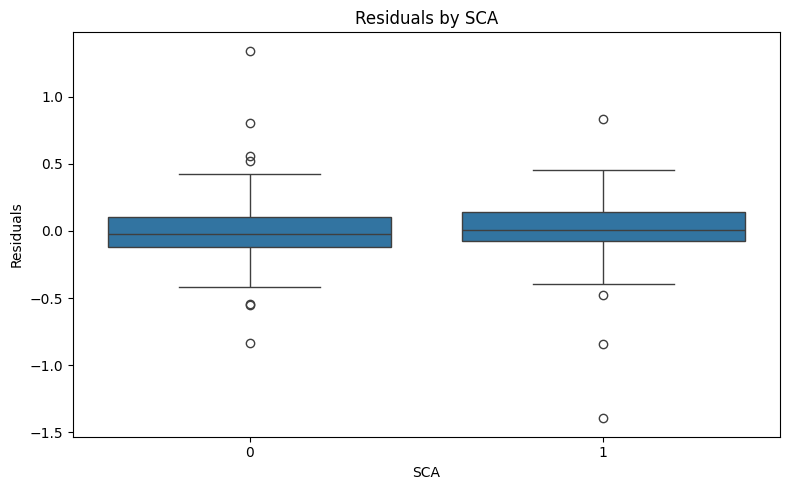

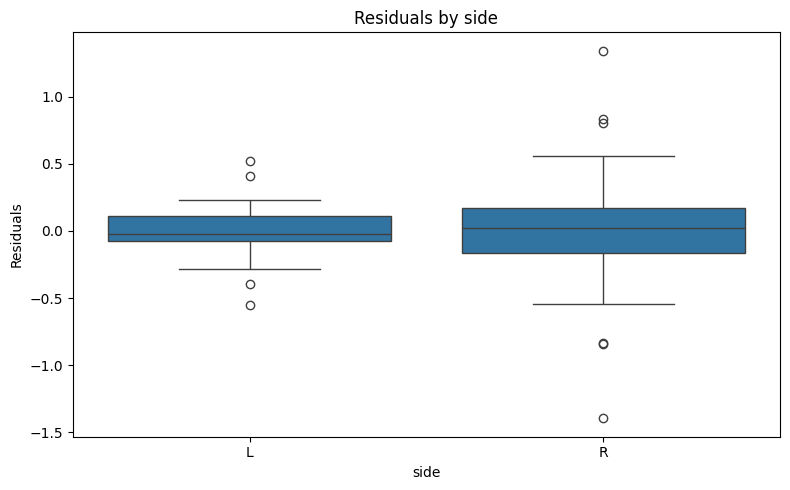

In [47]:
###	Plot residuals by each categorical predictor ###
### Diagnostic for normality/heteroscedastity/outliers ###

# Fit the linear mixed model
model = smf.mixedlm("iso1_centered ~ C(SCA) + C(side)", data=combined_centered, groups=combined_centered["ori_subjName"])
result = model.fit()

# Extract residuals and add to DataFrame
df["residuals"] = result.resid  # model residuals

# Plot residuals by each categorical variable
categorical_vars = ["SCA", "side"]

for cat_var in categorical_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=cat_var, y="residuals", data=df)
    plt.title(f"Residuals by {cat_var}")
    plt.xlabel(cat_var)
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()


In [10]:
#################  verifications of correlations, collinearity  #################
df = combined_centered

# print correlation
#print(df[['Age', 'Age_onset']].corr())
#print(df[['CAG', 'SARA']].corr())
#print(df[['CAG', 'Age_onset']].corr())

#print(df['Age_onset'].isnull().sum())
#print(df[df['Age_onset'].isnull()])

print("Number of rows in DataFrame:", len(df))
print("DataFrame shape:", df.shape)
print("Unique subject names:", df['ori_subjName'].unique())
print("Rows with NaN in groups:", df[df["ori_subjName"].isnull()])

#print("Max index:", df.index.max())
#print("Unique subjects:", df["ori_subjName"].nunique())
#print("Rows per subject:", df["ori_subjName"].value_counts())
#print("Group labels shape:", df['ori_subjName'].shape)
#print("Group sizes:")
#print(df.groupby("ori_subjName").size())
#print("Row indices for each group:")
#print(groups)

Number of rows in DataFrame: 160
DataFrame shape: (160, 79)
Unique subject names: ['L00001PJ' 'L00004PA' 'L00011EG' 'L00023EA' 'L00027EF' 'L00030CA'
 'L00031CP' 'L00036DC' 'L001013LF' 'L001019DA' 'L001020HG' 'L001022LM'
 'L001029DJ' 'L001032SG' 'L001033BM' 'L001037GA' 'L001039CD' 'L001040BF'
 'L001049BD' 'L001060MJ' 'L001065BC' 'L001068RA' 'L001069DB' 'L001073PM'
 'L001075HJ' 'L001076SC' 'L001077MR' 'L001079LP' 'L001083RB' 'L001084CJ'
 'L001085BN' 'L001087RN' 'L001090RD' 'L001091MR' 'L001093TL' 'L001095MP'
 'L001096BC' 'L001099GL' 'L001100PY' 'L001101JO' 'flip-R00001PJ'
 'flip-R00004PA' 'flip-R00011EG' 'flip-R00023EA' 'flip-R00027EF'
 'flip-R00030CA' 'flip-R00031CP' 'flip-R00036DC' 'flip-R001013LF'
 'flip-R001019DA' 'flip-R001020HG' 'flip-R001022LM' 'flip-R001029DJ'
 'flip-R001032SG' 'flip-R001033BM' 'flip-R001037GA' 'flip-R001039CD'
 'flip-R001040BF' 'flip-R001049BD' 'flip-R001060MJ' 'flip-R001065BC'
 'flip-R001068RA' 'flip-R001069DB' 'flip-R001073PM' 'flip-R001075HJ'
 'flip-R001076SC

In [11]:
df = combined_centered
print(df['ori_subjName'].isna().sum())

print(df['ori_subjName'].unique()[:50])
print(df['ori_subjName'].dtype)


0
['L00001PJ' 'L00004PA' 'L00011EG' 'L00023EA' 'L00027EF' 'L00030CA'
 'L00031CP' 'L00036DC' 'L001013LF' 'L001019DA' 'L001020HG' 'L001022LM'
 'L001029DJ' 'L001032SG' 'L001033BM' 'L001037GA' 'L001039CD' 'L001040BF'
 'L001049BD' 'L001060MJ' 'L001065BC' 'L001068RA' 'L001069DB' 'L001073PM'
 'L001075HJ' 'L001076SC' 'L001077MR' 'L001079LP' 'L001083RB' 'L001084CJ'
 'L001085BN' 'L001087RN' 'L001090RD' 'L001091MR' 'L001093TL' 'L001095MP'
 'L001096BC' 'L001099GL' 'L001100PY' 'L001101JO' 'flip-R00001PJ'
 'flip-R00004PA' 'flip-R00011EG' 'flip-R00023EA' 'flip-R00027EF'
 'flip-R00030CA' 'flip-R00031CP' 'flip-R00036DC' 'flip-R001013LF'
 'flip-R001019DA']
object


In [12]:
print(combined_centered["UMAP1_U2"].describe())
#print(combined_CAG_only_SCA['CAG'].describe())

count    160.000000
mean       0.479371
std        2.995892
min       -4.870023
25%       -2.110290
50%        0.277723
75%        2.843532
max        6.466691
Name: UMAP1_U2, dtype: float64


In [49]:
#########################  Test for group difference using LMM  #######################

combined_BIOSCA = combined[combined['CodeICM'] == 'BIOSCA']
#df = combined_BIOSCA           ####  testing BIOSCA only  ####
df = combined_centered          ####  testing all  ####

##########  standardize the iso1 by CodeICM  ##########
df['iso1_zscore'] = df.groupby('CodeICM')['iso1'].transform(
    lambda x: (x - x.mean()) / x.std()
)

model = smf.mixedlm(
    formula="iso1_centered ~ C(SCA) + C(Time_point) + Age_centered + C(side)", # DEFAULT
#    formula="iso1_centered ~ C(SCA) * C(side) + C(Time_point) ", # test hemisphere interaction    
    #formula="iso1_centered ~ C(SCA) + Age_centered + C(side)", 
    #formula="iso1_centered ~ SCA + C(Time_point)+ C(side) + C(Sex)", 
    #formula="iso1_centered ~ SCA + C(Time_point) + C(CodeICM) + C(side)",    # adding project as covariate
    #formula="iso1_centered ~ SCA + Age_centered + C(CodeICM) + C(side)",    # adding project as covariate    
    #formula="iso1_zscore ~ SCA + Time_point",            # testing Z-score 
    #formula="iso1_centered ~ SCA + Time_point + SCA:Time_point",  # include interaction if you want
    data=df,
    groups=df["ori_subjName"]  # random intercept for subject
)
result = model.fit()
print(result.summary())



            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: iso1_centered
No. Observations:   160     Method:             REML         
No. Groups:         80      Scale:              0.1554       
Min. group size:    2       Log-Likelihood:     -295.4542    
Max. group size:    2       Converged:          Yes          
Mean group size:    2.0                                      
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           1.603    0.759  2.113 0.035  0.116  3.090
C(SCA)[T.1]        -2.180    0.983 -2.217 0.027 -4.107 -0.253
C(Time_point)[T.2]  0.092    0.099  0.933 0.351 -0.101  0.285
C(Time_point)[T.3]  0.008    0.143  0.055 0.956 -0.273  0.288
C(side)[T.R]       -1.646    0.940 -1.752 0.080 -3.487  0.196
Age_centered       -0.028    0.035 -0.800 0.424 -0.096  0.040
Group Var          1

In [14]:
###########  Performing the Wald test to see if there are significant differences among time points  ###########

## NOTE: this is only when time_point is in the LMM model !
combined_centered['Time_point']  # check out the Time_point column values
print(result.model.exog_names)   # print out the model exog_names, to be used to do the Wald test

# With two time point levels (besides the reference)
hypotheses = ['C(Time_point)[T.2] = 0', 'C(Time_point)[T.3] = 0']  # adjust levels
wald_test = result.f_test(hypotheses)
print(wald_test)


['Intercept', 'C(SCA)[T.1]', 'C(Time_point)[T.2]', 'C(Time_point)[T.3]', 'C(side)[T.R]']
<F test: F=0.14351384079907406, p=0.8664237895357874, df_denom=155, df_num=2>


In [15]:
###################################   Likelihood ratio test  ##################################
#############################  LRT as an alternative to p-values  #############################

# comparing log-likelihoods of nested models, for small sample size and the testing of a key effect
# Use reml=False for both models. REML (restricted maximum likelihood) is good for estimating variance components
# but not for comparing models with different fixed effects.
# Using a chi-square distribution with df=1 because testing 1 parameter (CAG_centered).   
#df = combined
df = combined_centered
formula = "iso1_centered ~ C(SCA) + Time_point + C(side)"
reduced_formula = "iso1_centered ~ Time_point + C(side)"
#formula = "iso1_centered ~ C(SCA) + Time_point + C(side) + C(CodeICM)"
#reduced_formula = "iso1_centered ~ Time_point + C(side) + C(CodeICM)"

from scipy.stats import chi2

# Full model with SCA and Time_point
model_full = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result_full = model_full.fit(reml=False)

# Reduced model with only Time_point (i.e., removing SCA)
model_reduced = smf.mixedlm(formula = reduced_formula, data=df, groups=df["ori_subjName"])
result_reduced = model_reduced.fit(reml=False)

# Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)  # LRT statistic
df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # difference in degrees of freedom
p_value = stats.chi2.sf(lr_stat, df_diff)  # chi-square p-value

print(f"Likelihood Ratio Test statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {p_value:.4g}")

Likelihood Ratio Test statistic: 4.5113
Degrees of freedom: 1
p-value: 0.03367


In [16]:
#####################################    Model selection    #######################################
###################  Calculating the ICC: intraclass correlation coefficients  ####################
#################   Testing ICC to decide to include the random intercept or not  #################

# To understand what is the proportion of variability in random intercept
# Random intercept variance (subject) / (Random intercept variance (subject) + Residual variance (error))

## NOTE:  Based on the result of the LMM test in the cell above 

# Extract random intercept variance (subject-level variance)
subject_var = result.cov_re.iloc[0, 0]

# Extract residual (within-subject / error) variance
residual_var = result.scale

print(f"Random intercept variance (subject): {subject_var:.2f}")
print(f"Residual variance (error): {residual_var:.2f}")

icc = subject_var / (subject_var + residual_var)
print(f"Intraclass Correlation Coefficient (ICC): {icc:.3f}")


Random intercept variance (subject): 17.49
Residual variance (error): 0.16
Intraclass Correlation Coefficient (ICC): 0.991


In [17]:
###################################   Likelihood ratio test  ##################################
#################   Testing LRT to decide to include the random slope or not  #################

# Define the formula explicitly
#formula = "UMAP1_U2_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)"
formula = "iso1_centered ~ C(SCA) + C(side)"


# Model 1: Random intercept only
model_reduced = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"]
)
result_reduced = model_reduced.fit()

# Model 2: Random intercept + random slope for CAG_centered
model_full = smf.mixedlm(
    formula=formula,
    data=df,
    groups=df["ori_subjName"],
    re_formula="~SCA"
)
result_full = model_full.fit()

# Perform Likelihood Ratio Test
lr_stat = 2 * (result_full.llf - result_reduced.llf)  # LRT statistic
df_diff = result_full.df_modelwc - result_reduced.df_modelwc  # difference in degrees of freedom
p_value = stats.chi2.sf(lr_stat, df_diff)  # chi-square p-value

print(f"Likelihood Ratio Test statistic: {lr_stat:.4f}")
print(f"Degrees of freedom: {df_diff}")
print(f"p-value: {p_value:.4g}")

Likelihood Ratio Test statistic: 0.8278
Degrees of freedom: 2
p-value: 0.6611


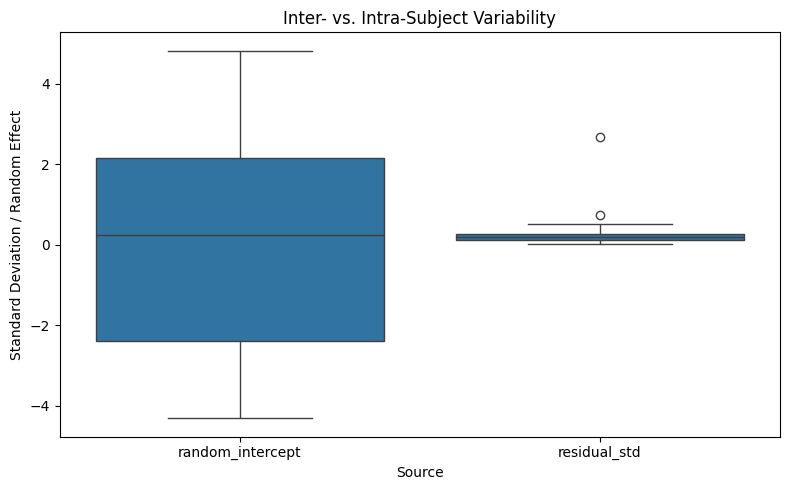

In [18]:
#########################  Plot inter vs intra subject variability  #########################

df = combined_CAG_only_SCA_centered
formula = "UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)"
model = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result = model.fit()

# Extract random effects (inter-subject variability)
random_effects = pd.DataFrame(result.random_effects).T
random_effects.columns = ['random_intercept']

# Extract residuals (intra-subject variability)
df["residuals"] = result.resid
residuals_std_by_subject = df.groupby("ori_subjName")["residuals"].std().reset_index()
residuals_std_by_subject.columns = ["ori_subjName", "residual_std"]

# Merge both
plot_df = random_effects.merge(residuals_std_by_subject, left_index=True, right_on="ori_subjName")

# Melt for seaborn boxplot
plot_df_melted = plot_df.melt(id_vars="ori_subjName", value_vars=["random_intercept", "residual_std"],
                              var_name="Source", value_name="Value")

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x="Source", y="Value", data=plot_df_melted)
plt.title("Inter- vs. Intra-Subject Variability")
plt.ylabel("Standard Deviation / Random Effect")
plt.tight_layout()
plt.show()


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


              Group  CAG_centered
L001013LF -2.973572     -0.002335
L001029DJ  4.594037      0.003608
L001033BM -1.745394     -0.001371
L001039CD  0.856399      0.000673
L001068RA -0.220546     -0.000173


C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.001740
  warnings.warn(msg, ConvergenceWarning)
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


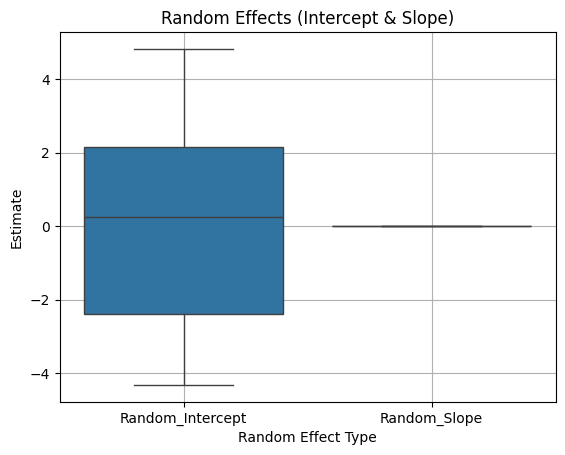

In [19]:
#################  model and plot random intercept and random slope  ###################

model_lmm = smf.mixedlm(
#    formula="iso1_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)",
    formula="UMAP1_U2_centered ~ CAG_centered + Age_onset_centered + C(side)",
    data=df,
    groups=df["ori_subjName"],
    re_formula="~CAG_centered"  # random intercept + slope for CAG_centered
)
result_lmm = model_lmm.fit()

##################  plot of random effect  ##################
result_lmm.random_effects

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
print(re_df.head())

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')
re_df.columns = ['Random_Intercept', 'Random_Slope']

re_df = re_df.reset_index().melt(id_vars='index', var_name='Effect', value_name='Value')
sns.boxplot(data=re_df, x='Effect', y='Value')
plt.title("Random Effects (Intercept & Slope)")
plt.xlabel("Random Effect Type")
plt.ylabel("Estimate")
plt.grid(True)
plt.show()

In [20]:
##############################################    WIP   ###############################################

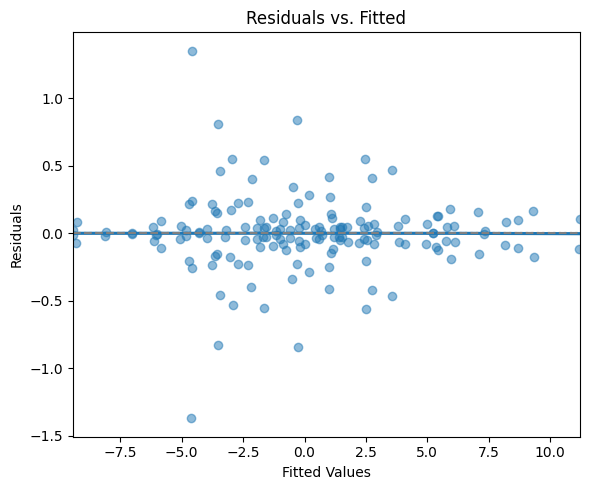

<Figure size 600x500 with 0 Axes>

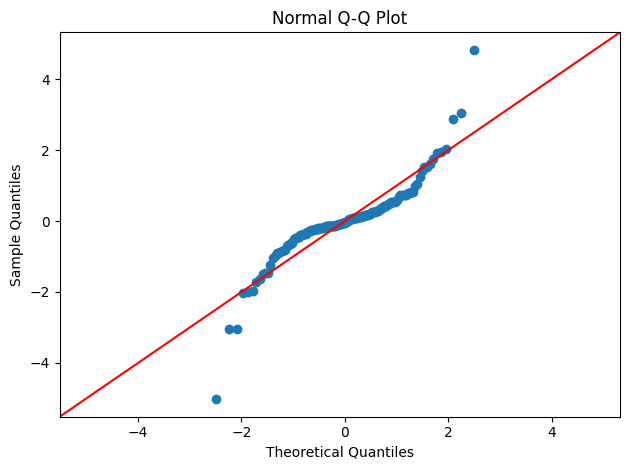

In [21]:
###################################   Diagnostic of the model  ##################################
#################  For Residuals: linearity, constant variance (homoscedasticity) and normality  #################

#######################  Residual versus fitted plots  #######################
#df = combined_CAG_only_SCA
df = combined_centered

# Fit your LMM
formula = "iso1_centered ~ C(SCA) + Time_point + C(side)"
model = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
result = model.fit()

# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

# Plot 1: Residuals vs. Fitted
plt.figure(figsize=(6, 5))
sns.residplot(x=fitted, y=residuals, lowess=True, scatter_kws={'alpha': 0.5})
plt.axhline(0, color='gray', linestyle='--')  # ← fixed line
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_Residual.png')

plt.show()

########################     QQ-plots of the residual   ######################
# Plot 2: Q-Q Plot
plt.figure(figsize=(6, 5))
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\SCA1_ctl_maxIso1_time1_2_QQ.png')

plt.show()




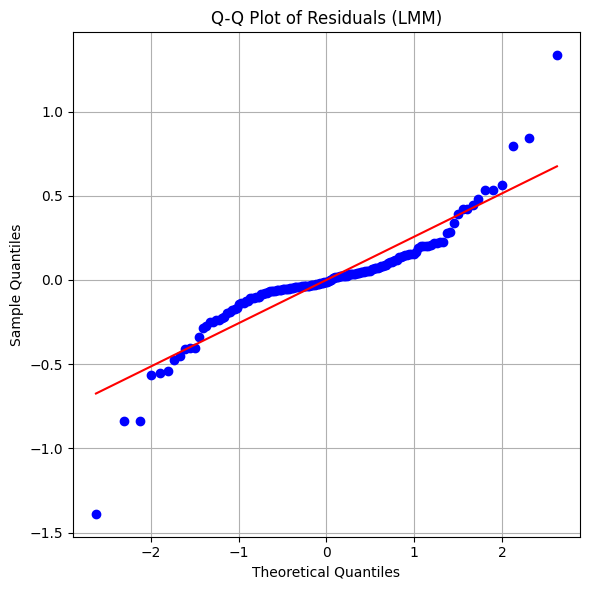

In [22]:
###########  Q-Q plot using stats.probplot instead of sm.qqplot as above  ###########
## sm.qqplot above for a quick check
## stats.probplot here for fine-grained control or integration into custom plotting pipelines

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (LMM)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

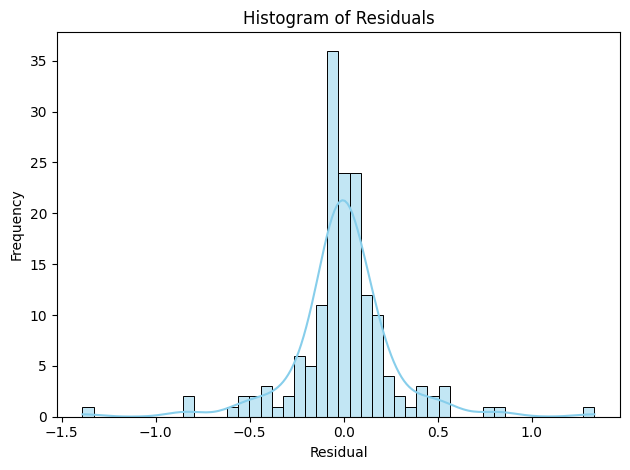

In [23]:
residuals = result.resid
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [24]:
##################  Normality test of the residual  ####################
formula = "UMAP1_U2_centered ~ C(SCA) + Time_point + C(side)"
model = smf.mixedlm(formula = formula, data=df, groups=df["ori_subjName"])
residuals = result.resid

# shapiro: if p > 0.05, not normal
from scipy.stats import shapiro
shapiro_stat, p_value = shapiro(result.resid)
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

Shapiro-Wilk p-value: 0.0000


In [25]:
##################  Normality test of the residual  ####################
# Kolmogorov-Smirnov: if p > 0.05, not normal
# The K-S test is sensitive to outliers and assumes known parameters (mean and std). 
# When applied to estimated residuals, it can be conservative or misleading.
# It’s generally less powerful than the Shapiro-Wilk test for normality.
from scipy.stats import kstest, norm
ks_stat, ks_p = kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print(f"Kolmogorov-Smirnov test p-value: {ks_p:.4f}")

Kolmogorov-Smirnov test p-value: 0.0006


In [26]:
#########################	 Heteroscedasticity Tests  ##########################
## If you’re concerned about non-constant variance: Breusch-Pagan test (for linear models):

## use result.resid from above

from statsmodels.stats.diagnostic import het_breuschpagan
_, pval, _, _ = het_breuschpagan(result.resid, result.model.exog)
print("Breusch-Pagan p-value:", pval)


Breusch-Pagan p-value: 0.04285207072277655


In [27]:
##################   If needed: Use OLS for a workaround of heteroscedasticity   ####################
# If you're just estimating fixed effects and don’t need random effects:

# Prepare the data
df = combined_centered

#X = df[["CAG", "Time_point"]]  ## to compare results, WITHOUT Age_onset
X = df[["SCA", "Time_point"]]
X = sm.add_constant(X)  # Adds the intercept term
y = df["iso1_centered"]

# Fit OLS model with robust standard errors
ols_model = sm.OLS(y, X).fit(cov_type='HC3')  # HC3 = robust SE against heteroscedasticity
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:          iso1_centered   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     5.022
Date:                Fri, 25 Jul 2025   Prob (F-statistic):            0.00769
Time:                        18:19:37   Log-Likelihood:                -456.23
No. Observations:                 160   AIC:                             918.5
Df Residuals:                     157   BIC:                             927.7
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0133      1.016     -0.013      0.9

In [28]:
##############################  Plots studying the relationship between shape and CAG  ############################### 

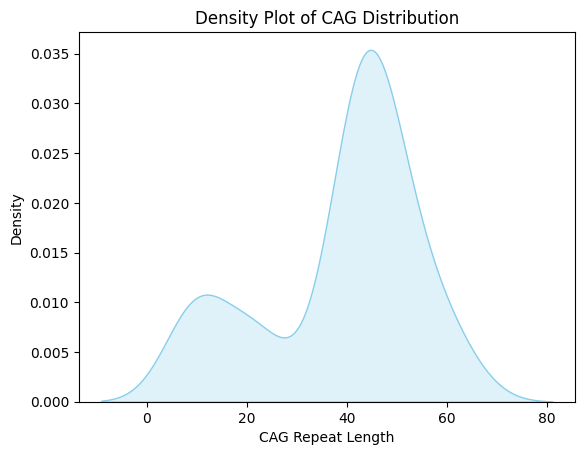

In [29]:
####################  Density plot of the CAG distribution  #####################

sns.kdeplot(data=df, x='CAG', fill=True, color='skyblue')
plt.xlabel('CAG Repeat Length')
plt.ylabel('Density')
plt.title('Density Plot of CAG Distribution')
plt.show()


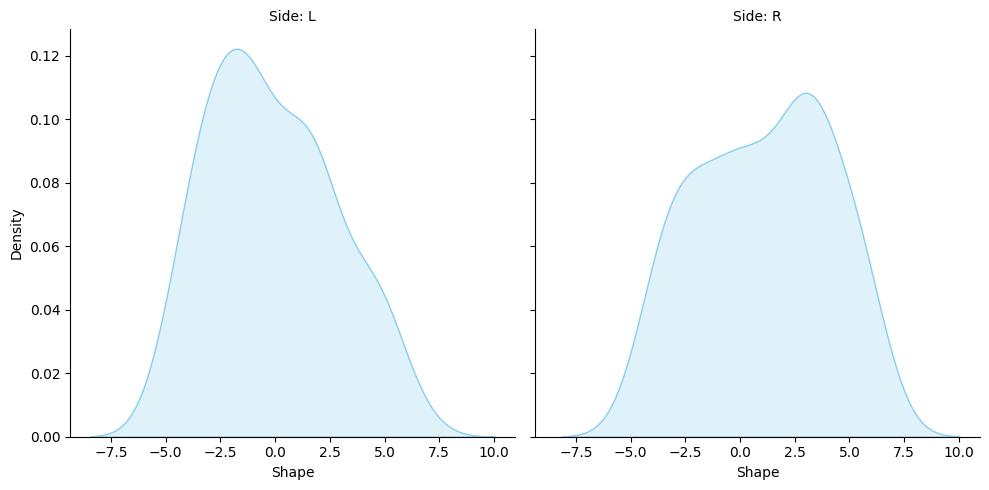

In [30]:
######################   Density plot of shape for the two hemispheres  #######################

g = sns.FacetGrid(df, col="side", height=5, aspect=1)
#g.map_dataframe(sns.kdeplot, x="iso1", fill=True, color='skyblue')
g.map_dataframe(sns.kdeplot, x="UMAP1_U2", fill=True, color='skyblue')
g.set_axis_labels("Shape", "Density")
g.set_titles("Side: {col_name}")
plt.tight_layout()
plt.show()


In [31]:
###################  Boxplots regressing out covariates  ###################

# Define predictors and add constant
X = df[['Age', 'Age_onset']]
#X = df[['Age', 'Age_onset']]
X = sm.add_constant(X)

# Fit linear model: isomap ~ Age + Age_onset
#model = sm.OLS(df['iso1'], X).fit()
model = sm.OLS(df['UMAP1_U2'], X).fit()
df['shape_resid'] = model.resid  # residuals = isomap adjusted for Age and Age_onset

# Bin CAG into quartiles (or use custom bins)
df['CAG_bin'] = pd.qcut(df['CAG'], q=4)

# Plot residualized isomap vs binned CAG
sns.boxplot(data=df, x='CAG_bin', y='shape_resid', palette='Set2')
plt.xlabel('CAG Quartile Bin')
plt.ylabel('Shape (adjusted for Age & Age_onset)')
plt.title('Adjusted shape vs CAG Bins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


MissingDataError: exog contains inf or nans

In [ ]:
#############################  model fit plot, fixed plus random effect  #############################

import seaborn as sns
import matplotlib.pyplot as plt

# Predict values from the full mixed effects model (includes random effects)
df["predicted_U12"] = result.predict(df)

# Scatter actual data
sns.scatterplot(data=df, x="CAG_centered", y="UMAP1_U2_centered", label="Actual data")

# Add subject-level fitted line
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="predicted_iso1", color="red", label="LMM prediction")

plt.title("Predicted vs Actual U12 (LMM, includes subject random effects)")
plt.xlabel("CAG (centered)")
plt.ylabel("U12 (centered)")
plt.legend()
plt.show()


In [ ]:
###########  model fit without random effects  #############

import statsmodels.formula.api as smf

# Fit a simple OLS model (no random effects)
lm_result = smf.ols("UMAP1_U2_centered ~ CAG_centered + Age_centered + Age_onset_centered + C(side)", data=df).fit()

# Predict values
df["ols_pred"] = lm_result.predict(df)

# Plot
sns.scatterplot(data=df, x="CAG_centered", y="iso1_centered", label="Actual data")
sns.lineplot(data=df.sort_values("CAG_centered"), 
             x="CAG_centered", y="ols_pred", color="green", label="OLS prediction")

plt.title("Prediction from Simple Linear Model (Fixed Effects Only)")
plt.xlabel("CAG (centered)")
plt.ylabel("Shape (centered)")
plt.legend()
plt.show()


In [ ]:
##################  Compare models with and without interaction term  ###################
################## Split the data into left and right hemisphere subsets and run separate models  ###################
##################  Note that this count as multiple testing, correction needed  ####################
df = combined_CAG_only_SCA_centered

def test_LMM(df,measure):
    x_var = 'CAG_centered'          # DEFAULT
    covariates = 'Age_onset_centered + C(side)'  # DEFAULT 

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

def test_LMM_interaction_side(df,measure):
    x_var = 'CAG_centered*C(side)'           # Estimating different slopes and intercepts for left and right hemispheres
                                             # Testing whether, for example, CAG influences left and right hemispheres differently 
    covariates = 'Age_onset_centered'        # If moving side to x_var as interaction term

    model_lmm = smf.mixedlm(
        formula=f"{measure} ~ {x_var} + {covariates}", 
        data=df,
        groups=df['ori_subjName']
    )
    result = model_lmm.fit()
    print(result.summary())

####################################################################################################
df = combined_CAG_only_SCA_centered

df_L = df[df['side'] == 'L']
df_R = df[df['side'] == 'R']

curMeasure = 'UMAP1_U2_centered'

test_LMM(df,curMeasure)
print('__________________Interaction side____________________')
print()
test_LMM_interaction_side(df,curMeasure)
print('__________________Left hemisphere____________________')
print()
test_LMM(df_L,curMeasure)
print('__________________Right hemisphere___________________')
print()
test_LMM(df_R,curMeasure)

In [ ]:
#### Is the hemispheric difference in shape different depending on SCA type? ####
# Whether there's a general left vs. right difference in shape (C(side)).
# Whether different SCA types show different average shape (C(SCA)).
# Whether hemisphere differences (left-right) are different for different SCA types (C(side):C(SCA) — the interaction).

df = combined_centered  ###  testing at least two different SCA types

model = smf.mixedlm(
#    formula="iso1_centered ~ C(side) * C(SCA) + Age_centered + Sex",   # centered or not, same p-val
#    formula="iso1 ~ C(side) * C(SCA) + Age + Sex",   
    formula="UMAP1_U2_centered ~ C(side) * C(SCA) + Age_centered + Sex",      
    data=df,
    groups=df['ori_subjName']
)
result = model.fit()
print(result.summary())


In [ ]:
#####################  Study the relationship between age and age_onset  ######################
print(df[['Age', 'Age_onset']].corr())

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='Age', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('Age at Assessment')
plt.title('Relationship between Age and Age of Onset')
plt.tight_layout()
plt.show()


In [ ]:
##################  Study the relationship between CAG and age_onset
print(df[['CAG', 'Age_onset']].corr())

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.regplot(data=df, x='Age_onset', y='CAG', scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

plt.xlabel('Age of Onset')
plt.ylabel('CAG')
plt.title('Relationship between CAG and Age of Onset')
plt.tight_layout()
plt.show()
